
Threshold = 0.00
Liczba cech po selekcji: 30
Usunięte cechy (0):
 - Brak usuniętych cech

Threshold = 2.00
Liczba cech po selekcji: 10
Usunięte cechy (20):
 - mean smoothness
 - mean compactness
 - mean concavity
 - mean concave points
 - mean symmetry
 - mean fractal dimension
 - radius error
 - texture error
 - smoothness error
 - compactness error
 - concavity error
 - concave points error
 - symmetry error
 - fractal dimension error
 - worst smoothness
 - worst compactness
 - worst concavity
 - worst concave points
 - worst symmetry
 - worst fractal dimension

Threshold = 4.00
Liczba cech po selekcji: 9
Usunięte cechy (21):
 - mean smoothness
 - mean compactness
 - mean concavity
 - mean concave points
 - mean symmetry
 - mean fractal dimension
 - radius error
 - texture error
 - perimeter error
 - smoothness error
 - compactness error
 - concavity error
 - concave points error
 - symmetry error
 - fractal dimension error
 - worst smoothness
 - worst compactness
 - worst concavity

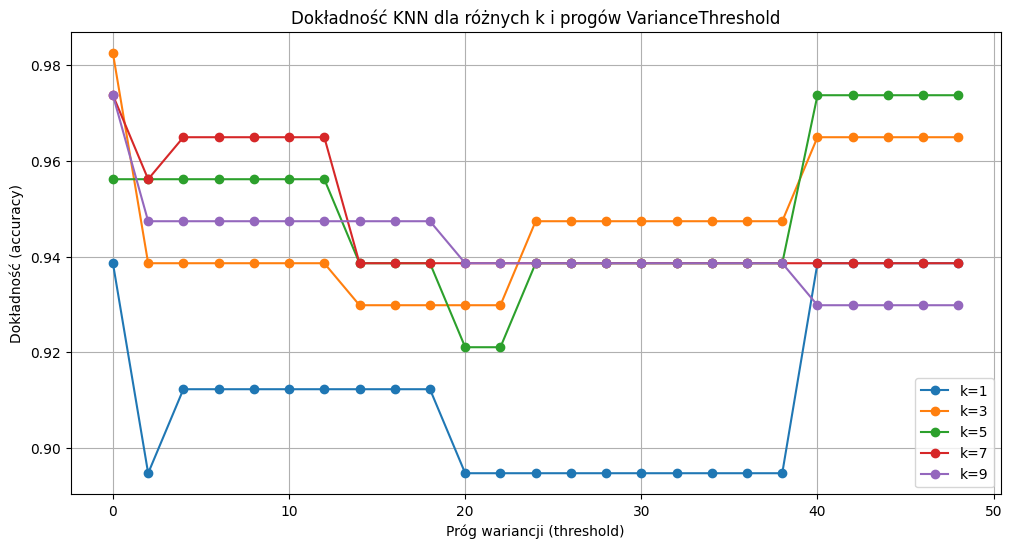

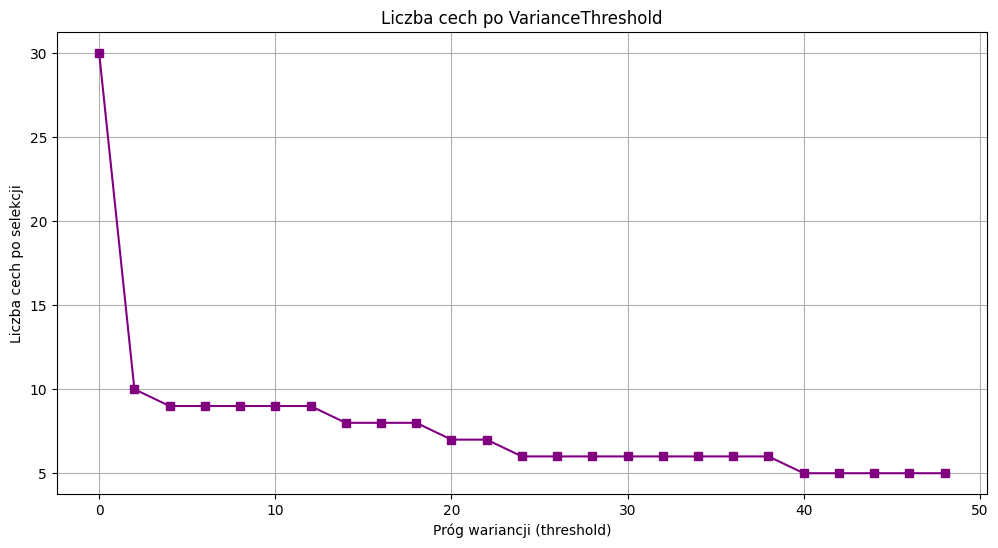

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import VarianceThreshold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Wczytaj dane
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = np.array(data.feature_names)

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Parametry do testu
thresholds = np.arange(0.0, 50.0, 2.0)
k_values = [1, 3, 5, 7, 9]

# Wyniki: {k: [accuracy dla każdego threshold]}
results = {k: [] for k in k_values}
num_features = []

for t in thresholds:
    selector = VarianceThreshold(threshold=t)

    try:
        # Selekcja cech na zbiorze treningowym
        X_train_sel = selector.fit_transform(X_train)
        X_test_sel = selector.transform(X_test)

        # Maska wybranych cech
        selected_mask = selector.get_support()
        selected_features = feature_names[selected_mask]
        removed_features = feature_names[~selected_mask]

        # Liczba cech po selekcji
        num_features.append(X_train_sel.shape[1])

        print(f"\nThreshold = {t:.2f}")
        print(f"Liczba cech po selekcji: {X_train_sel.shape[1]}")
        print(f"Usunięte cechy ({len(removed_features)}):")

        if len(removed_features) > 0:
            for feature in removed_features:
                print(f" - {feature}")
        else:
            print(" - Brak usuniętych cech")

        # Skalowanie po selekcji cech
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_sel)
        X_test_scaled = scaler.transform(X_test_sel)

        # Klasyfikacja dla różnych k
        for k in k_values:
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_train_scaled, y_train)
            acc = knn.score(X_test_scaled, y_test)
            results[k].append(acc)

    except ValueError:
        # Gdy próg usunie wszystkie cechy
        num_features.append(0)

        print(f"\nThreshold = {t:.2f}")
        print("Wszystkie cechy zostały usunięte.")

        for k in k_values:
            results[k].append(np.nan)

# Wykres porównawczy accuracy
plt.figure(figsize=(12, 6))
for k in k_values:
    plt.plot(thresholds, results[k], marker='o', label=f'k={k}')

plt.xlabel("Próg wariancji (threshold)")
plt.ylabel("Dokładność (accuracy)")
plt.title("Dokładność KNN dla różnych k i progów VarianceThreshold")
plt.grid(True)
plt.legend()
plt.show()

# Wykres liczby cech po selekcji
plt.figure(figsize=(12, 6))
plt.plot(thresholds, num_features, marker='s', color='purple')
plt.xlabel("Próg wariancji (threshold)")
plt.ylabel("Liczba cech po selekcji")
plt.title("Liczba cech po VarianceThreshold")
plt.grid(True)
plt.show()